In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("tab10")
plt.style.use("../../plotStyle.mplstyle")

In [2]:
df = pd.read_csv("memory.csv")
df["correct_conf"] = df.apply(lambda x: 100 - x.response if x.answer == 0 else x.response, axis=1)
# df["correct1"] = (df.response > 50).astype(int) == df.answer
df["correct"] = ((df.response > 50).astype(int) == df.answer) & (df["response"] != 50)
df["consistent"] = ((df["worldtype"] == 1) & (df["probe_obj"] == "teleport_consistent")) | ((
    df["worldtype"] == 2
) & (df["probe_obj"] == "noteleport_consistent"))
df["obj_type"] = df[["consistent", "probe_obj"]].apply(
    lambda x: {(True, "teleport_consistent"): "hit",
               (True, "noteleport_consistent"): "hit",
               (False, "teleport_consistent"): "nohit",
               (False, "noteleport_consistent"): "nohit",
               (False, "nocol"): "background"}[tuple(x)], axis=1)
df["confidence"] = np.abs(df["response"] - 50)

In [3]:
df.groupby(["consistent"]).correct.mean()

consistent
False    0.512998
True     0.694268
Name: correct, dtype: float64

In [4]:
df.query("probe_obj == 'nocol'").correct.mean()

0.4863013698630137

In [5]:
rts = df.groupby("pid").rt.mean().reset_index()
rts = rts[rts.rt < np.quantile(rts.rt, 0.10)]
print(rts)

                         pid           rt
20  5f467b0a0d1aef037515c8c9  6373.444444
31  614895cb03b189f771ad1267  5901.888889
40  634868460f7419e22957fb59  2828.333333
44  63d42902a85ae3e7b4920266  6064.111111
46  63e8326b8d067b28655586fb  6075.333333
49  6539204539fa1cc8a5f183e5  5325.444444
52  656e8efb6e6610ae2d831f07  6067.222222
54  6636396184346e2371d067ec  5117.333333
74  66a9d46ff5d39bbede9f2e92  4098.666667
83  66ccdfaee9ee00c604629b06  5740.000000


In [6]:
df.pid.nunique()

99

In [7]:
from ast import literal_eval
pred = pd.read_csv("predictions.csv")
pred["mae"] = 0

for idx, row in pred.iterrows():
    pred.loc[idx, "mae"] = sum(np.abs(row.true_x - np.array(literal_eval(row["clickPositions"])))) / 10

# normalize by maximum deviation for each world
pred["mae"] = pred.groupby("world")["mae"].transform(lambda x: x / x.max())
# look at people who were weird
weirdos = []

for idx, row in pred.query("world == 'catch'").iterrows():
    row_pred = literal_eval(row["clickPositions"])
    true_x = row.sim_x_result1 if row.worldtype == 1 else row.sim_x_result2
    if sum(abs(true_x - x) > 50 for x in row_pred) > 5:
        weirdos.append((row.pid, row.world, row.worldtype, max(abs(true_x - x) for x in row_pred)))
df = df[~df.pid.isin([w[0] for w in weirdos])]

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_89210/3876920670.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  p.set_xticklabels(["entry scenes", "exit scenes"])


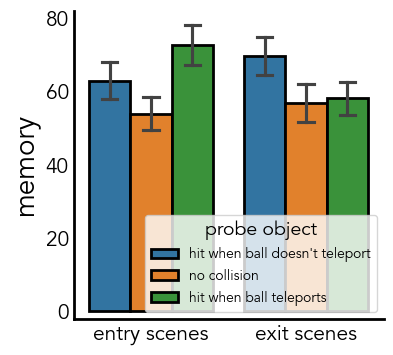

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
p = sns.barplot(df, x="worldtype", y="correct_conf", hue="probe_obj", errorbar="ci", palette="tab10", ec="black", lw=2, capsize=0.3)
p.set_xlabel("")
p.set_ylim(-2)
p.set_xticklabels(["entry scenes", "exit scenes"])
p.set_ylabel("memory")
h, l = plt.gca().get_legend_handles_labels()
plt.legend(h, ["hit when ball doesn't teleport", "no collision", "hit when ball teleports"], title="probe object", loc="lower right")
plt.savefig("../../figures/teleport_memory_confidence.pdf", bbox_inches="tight")
# sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))

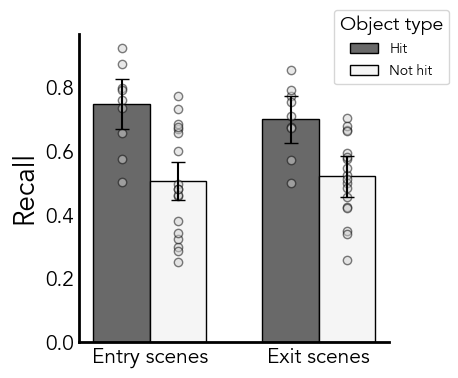

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))

x = 0
for worldtype in [1, 2]:
    gap = 0.5
    for consistent in [True, False]:
        color = "dimgray" if consistent else "whitesmoke"
        inner_gap = 0.5
        mean = df.loc[(df.worldtype == worldtype) & (df.consistent == consistent)].correct.mean()
        sem = 1.96 * df.loc[(df.worldtype == worldtype) & (df.consistent == consistent)].correct.sem()

        ax.bar(x, mean, yerr=sem, capsize=5, color=color, edgecolor="black", width=inner_gap, label=("Hit" if consistent else "Not hit") if worldtype == 1 else "")

        ax.set_xticks([inner_gap / 2, inner_gap * 2 + gap + inner_gap / 2], ["Entry scenes", "Exit scenes"])

        rawdata = df.loc[(df.worldtype == worldtype) & (df.consistent == consistent)]
        # print(rawdata)
        rawdata = rawdata.groupby(["world", "probe_obj"]).correct.mean()
        rawdata += np.random.normal(0, 0.02, size=len(rawdata))
        ax.scatter([x for _ in range(len(rawdata))], rawdata, c="lightgray", alpha=0.5, ec="k")
        x += inner_gap

    x += gap

# plt.bar(df["worldtype"], df["correct"], color=["tab:blue", "tab:orange"], edgecolor="black")
# p = sns.barplot(df, x="worldtype", y="correct", hue="consistent", errorbar="ci", palette="tab10", ec="black", lw=2, capsize=0.3)
# p.set_xlabel("")
# # p.set_ylim(-0.02)
# p.set_xticklabels(["Entry scenes", "Exit scenes"])
plt.ylabel("Recall")
plt.legend(title="Object type", bbox_to_anchor=(0.8, 1.1))
plt.savefig("../../figures/teleport_memory.pdf", bbox_inches="tight")

In [10]:
tmp = df.loc[df.probe_obj != "nocol"]
is_hit = ((tmp.worldtype == 1) & (tmp.probe_obj == "teleport_consistent")) | ((tmp.worldtype == 2) & (tmp.probe_obj == "noteleport_consistent"))

df1 = tmp.loc[is_hit].groupby(["world", "probe_obj"]).correct.mean().reset_index()
df2 = tmp.loc[~is_hit].groupby(["world", "probe_obj"]).correct.mean().reset_index()
# df1 = df.loc[(df.worldtype == 1) & (df.probe_obj.isin(["teleport_consistent", "noteleport_consistent"]))].groupby(["world", "probe_obj"]).correct.mean().reset_index()
# df2 = df.loc[(df.worldtype == 2) & (df.probe_obj.isin(["teleport_consistent", "noteleport_consistent"]))].groupby(["world", "probe_obj"]).correct.mean().reset_index()
combined = pd.merge(df1, df2, on=["world", "probe_obj"], suffixes=("_hit", "_nohit"))
combined

,world,probe_obj,correct_hit,correct_nohit
0,24,noteleport_consistent,0.687500,0.750000
1,24,teleport_consistent,0.928571,0.666667
2,25,noteleport_consistent,0.687500,0.692308
3,25,teleport_consistent,0.777778,0.444444
4,42,noteleport_consistent,0.777778,0.692308
5,42,teleport_consistent,0.750000,0.500000
6,45,noteleport_consistent,0.812500,0.454545
7,45,teleport_consistent,0.809524,0.666667
8,52,noteleport_consistent,0.523810,0.647059
9,52,teleport_consistent,0.866667,0.461538


In [11]:
from scipy.stats import ttest_1samp

diffs = (combined.correct_hit - combined.correct_nohit)
ttest_1samp(diffs, 0)

TtestResult(statistic=4.071672170758059, pvalue=0.0007939142194581535, df=17)

In [12]:
df.groupby("consistent").correct.mean()

consistent
False    0.512000
True     0.720755
Name: correct, dtype: float64

In [13]:
print(ttest_1samp(df.loc[(~df.consistent) & (df.probe_obj == "nocol")].groupby(["world", "probe_obj"]).correct.mean(), 0.5))
print(ttest_1samp(df.loc[(~df.consistent) & (df.probe_obj != "nocol")].groupby(["world", "probe_obj"]).correct.mean(), 0.5))
print(ttest_1samp(df.loc[df.consistent].groupby(["world", "probe_obj"]).correct.mean(), 0.5))
# ttest_1samp(df.loc[df.probe_obj == "nocol"].groupby("world").correct.mean(), 0.5)

TtestResult(statistic=-0.9871595237567505, pvalue=0.35247624869106386, df=8)
TtestResult(statistic=1.638406437107472, pvalue=0.11971101596704481, df=17)
TtestResult(statistic=7.788183792495753, pvalue=5.249431401908286e-07, df=17)


/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_89210/1629643863.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  p.set(xticklabels=["Entry", "Exit"], xlabel="", ylabel="Recall")


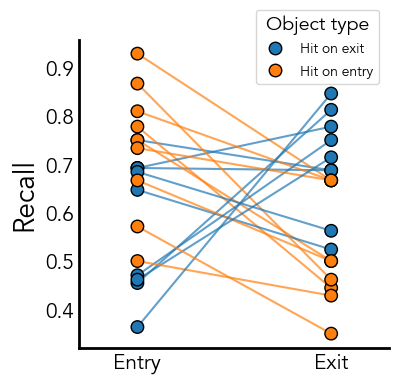

In [14]:
fig, ax = plt.subplots(figsize=(4, 4))

df1 = df.loc[(df.worldtype == 1) & (df.probe_obj.isin(["teleport_consistent", "noteleport_consistent"]))].groupby(["world", "probe_obj"]).correct.mean().reset_index()
df2 = df.loc[(df.worldtype == 2) & (df.probe_obj.isin(["teleport_consistent", "noteleport_consistent"]))].groupby(["world", "probe_obj"]).correct.mean().reset_index()
entryexit = pd.merge(df1, df2, on=["world", "probe_obj"], suffixes=("_entry", "_exit"))
tmp = pd.melt(entryexit, id_vars=["world", "probe_obj"], value_vars=["correct_entry", "correct_exit"], var_name="worldtype", value_name="recall")

p = sns.stripplot(tmp, x="worldtype", y="recall", hue="probe_obj", s=9, jitter=0.0, edgecolor="black", linewidth=1)
p.set(xticklabels=["Entry", "Exit"], xlabel="", ylabel="Recall")
handles, _ = plt.gca().get_legend_handles_labels()
p.legend().remove()
p.legend(handles=handles, labels=["Hit on exit", "Hit on entry"], title="Object type", bbox_to_anchor=(0.99, 1.12))

# connect entry and exit points with lines
for i in range(len(entryexit)):
    entry = entryexit.loc[i, "correct_entry"]
    exit = entryexit.loc[i, "correct_exit"]
    probe_obj = entryexit.loc[i, "probe_obj"]
    color = "tab:orange" if probe_obj == "teleport_consistent" else "tab:blue"
    plt.plot([0, 1], [entry, exit], color=color, alpha=0.7)

plt.xlim(-0.3, 1.3)
plt.savefig("../../figures/teleport_memory_paired.pdf", bbox_inches="tight", dpi=300)

# OLD

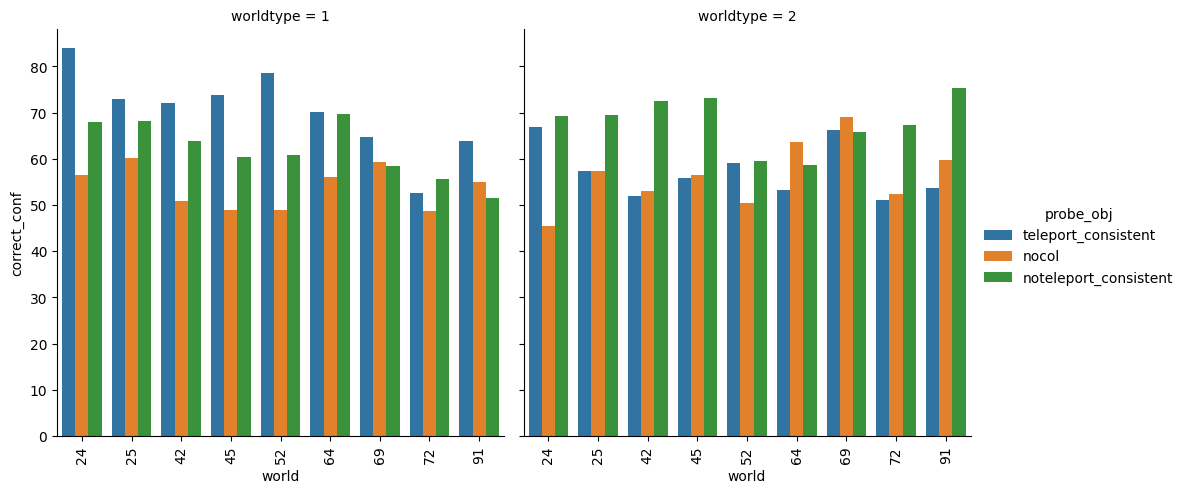

In [10]:
p = sns.catplot(df, x="world", y="correct_conf", hue="probe_obj", col="worldtype", palette="tab10", kind="bar", errorbar=None, order=sorted(df.world.unique()))
p.set_xticklabels(rotation=90)

# likelihood = pd.read_csv("../exp_bouncer_norm/likelihood.csv")
# p = sns.catplot(likelihood, x="world", y="response", hue="probe_obj", col="worldtype", palette="tab10", kind="bar", errorbar=None, order=sorted(df.world.unique()))
# p.set_xticklabels(rotation=90)
# p.set(title="likelihood by world")

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_65809/2148134883.py:3: UserWarning: FixedFormatter should only be used together with FixedLocator
  p.set_xticklabels(["not hit by ball", "hit by ball"])


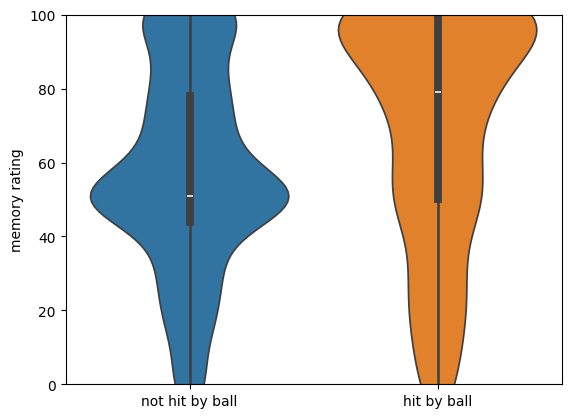

In [14]:
p = sns.violinplot(df, x="consistent", y="correct_conf", hue="consistent", palette="tab10", legend=False)
p.set_ylim(0, 100)
p.set_xticklabels(["not hit by ball", "hit by ball"])
plt.xlabel("")
p.set_ylabel("memory rating")
plt.savefig("../../figures/teleport_memory_consistent.pdf", bbox_inches="tight")

In [15]:
from scipy.stats import ttest_ind

print(ttest_ind(df[df.consistent].correct_conf, df[~df.consistent].correct_conf))
print(
    ttest_ind(
        df[(df.worldtype == 1) & (df.probe_obj == "teleport_consistent")].correct_conf,
        df[(df.worldtype == 1) & (df.probe_obj == "noteleport_consistent")].correct_conf,
    )
)
print(
    ttest_ind(
        df[(df.worldtype == 2) & (df.probe_obj == "teleport_consistent")].correct_conf,
        df[(df.worldtype == 2) & (df.probe_obj == "noteleport_consistent")].correct_conf,
    )
)
print(
    ttest_ind(
        df[(df.worldtype == 1) & (df.probe_obj == "teleport_consistent")].correct_conf,
        df[(df.worldtype == 1) & (df.probe_obj != "teleport_consistent")].correct_conf,
    )
)
print(
    ttest_ind(
        df[(df.worldtype == 2) & (df.probe_obj == "noteleport_consistent")].correct_conf,
        df[(df.worldtype == 2) & (df.probe_obj != "noteleport_consistent")].correct_conf,
    )
)
tmp = df.copy()
tmp = tmp.loc[tmp.probe_obj != "nocol"]
print("df", tmp.shape[0] - 2)
print(ttest_ind(tmp[tmp.consistent].correct_conf, tmp[~tmp.consistent].correct_conf))

Ttest_indResult(statistic=6.086397033074622, pvalue=1.8275011160000918e-09)
Ttest_indResult(statistic=2.6154911148330875, pvalue=0.009467501785851958)
Ttest_indResult(statistic=-3.236274210660711, pvalue=0.0013662082395008756)
Ttest_indResult(statistic=4.571885928610222, pvalue=6.53814650849785e-06)
Ttest_indResult(statistic=4.094820674911992, pvalue=5.167412904711147e-05)
df 508
Ttest_indResult(statistic=4.050941750969333, pvalue=5.898994419477518e-05)


In [11]:
df.probe_obj.unique()

array(['noteleport_consistent', 'nocol', 'teleport_consistent'],
      dtype=object)

In [32]:
likelihood = pd.read_csv("../exp_teleporter_norm/likelihood.csv")

In [33]:
likelihood["probe_obj"] = likelihood.probe_obj.str.replace("1", "teleport_consistent", regex=False)
likelihood["probe_obj"] = likelihood.probe_obj.str.replace("2", "noteleport_consistent", regex=False)
# likelihood.probe_obj

In [34]:
likelihood.groupby(["world", "worldtype", "probe_obj"]).response.count()

world  worldtype  probe_obj            
24     1          nocol                    7
                  noteleport_consistent    4
                  teleport_consistent      8
       2          nocol                    4
                  noteleport_consistent    5
                  teleport_consistent      2
25     1          nocol                    6
                  teleport_consistent      1
       2          nocol                    6
                  noteleport_consistent    8
                  teleport_consistent      9
42     1          nocol                    1
                  noteleport_consistent    5
                  teleport_consistent      7
       2          nocol                    7
                  noteleport_consistent    6
                  teleport_consistent      4
45     1          nocol                    4
                  noteleport_consistent    5
                  teleport_consistent      4
       2          nocol                    6
               

In [35]:
tmp = pd.merge(
    df.groupby(["world", "worldtype", "probe_obj"]).correct_conf.mean().reset_index(),
    likelihood.groupby(["world", "worldtype", "probe_obj"]).response.mean().reset_index(),
    on=["world", "worldtype", "probe_obj"],
)
tmp["consistent"] = ((tmp["worldtype"] == 1) & (tmp["probe_obj"] == "teleport_consistent")) | (( tmp["worldtype"] == 2) & (tmp["probe_obj"] == "noteleport_consistent"))

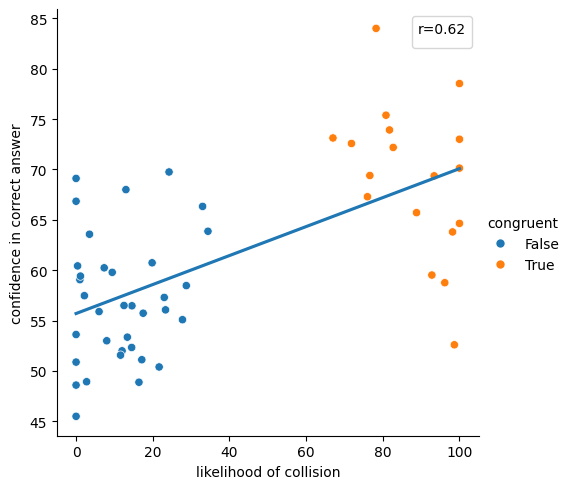

In [52]:
# tmp_ = tmp.query("(probe_obj == 'teleport_consistent') | (probe_obj == 'noteleport_consistent')")
# sns.relplot(tmp_, x="response", y="correct_conf", hue="probe_obj")
p = sns.relplot(tmp, x="response", y="correct_conf", hue="consistent")
sns.regplot(tmp, x="response", y="correct_conf", ci=False, scatter=False, ax=plt.gca())
plt.legend([], [], title=f"r={tmp.correct_conf.corr(tmp.response):.2f}")
p.set_ylabels("confidence in correct answer")
p.set_xlabels("likelihood of collision")
p.legend.set_title("congruent")

In [30]:
tmp = pd.merge(df.groupby(["consistent", "world", "worldtype", "probe_obj"]).correct_conf.mean().reset_index(),
               likelihood.groupby(["world", "worldtype", "probe_obj"]).response.mean().reset_index(),
               on=["world", "worldtype", "probe_obj"])
p = sns.lmplot(tmp, x="response", y="correct_conf", ci=False)
plt.title(f"r={tmp.correct_conf.corr(tmp.response):.2f}")

p = sns.lmplot(tmp, x="response", y="correct_conf", col="consistent")
for consistent, ax in p.axes_dict.items():
    subset = tmp[tmp.consistent == consistent]
    ax.set_title(f"consistent={consistent} r={subset.correct_conf.corr(subset.response):.2f}")
    ax.set_xlabel("collision likelihood")
    ax.set_ylabel("memory confidence")

NameError: name 'likelihood' is not defined

Text(0.5, 1.0, 'correct confidence by likelihood r=0.22')

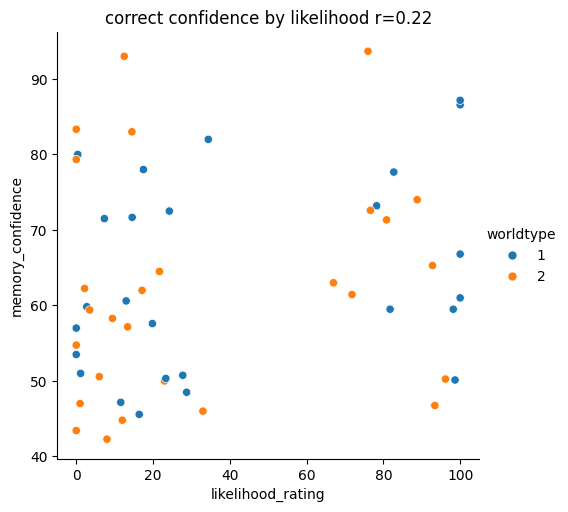

In [59]:
t1 = df.groupby(["consistent", "world", "worldtype", "probe_obj"]).agg(memory_confidence=("correct_conf", "mean"), memory_sem=("correct_conf", "sem")).reset_index()
t2 = likelihood.groupby(["world", "worldtype", "probe_obj"]).agg(likelihood_rating=("response", "mean"), likelihood_sem=("response", "sem")).reset_index()
# t2
tmp = pd.merge(t1, t2, on=["world", "worldtype", "probe_obj"])
# tmp = tmp[~tmp.world.isin(["lh_ll_unlink_plinko_0048", "lh_ll_unlink_plinko_0061", "lh_ll_unlink_plinko_0060" ])]
# p = sns.relplot(tmp, x="likelihood_rating", y="memory_confidence", ci=False, line_kws={"color": "black", "alpha": 0.5})
p = sns.relplot(tmp, x="likelihood_rating", y="memory_confidence", hue="worldtype", palette="tab10")
# plt.errorbar(tmp.likelihood_rating, tmp.memory_confidence, xerr=tmp.likelihood_sem, yerr=tmp.memory_sem, ls="none", alpha=0.25)
plt.title(f"correct confidence by likelihood r={tmp.memory_confidence.corr(tmp.likelihood_rating):.2f}")

Text(0.5, 1.0, 'correct by likelihood r=0.18')

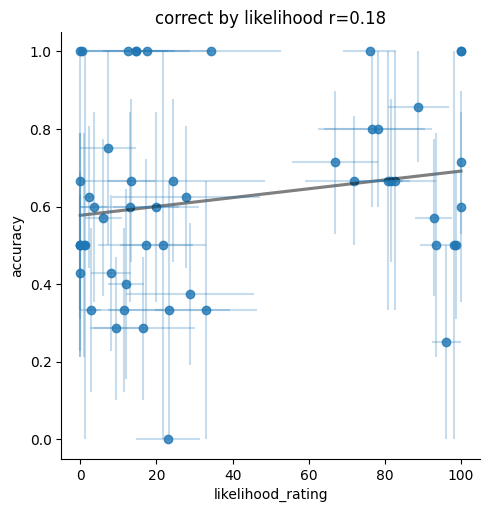

In [60]:
t1 = df.groupby(["consistent", "world", "worldtype", "probe_obj"]).agg(accuracy=("correct", "mean"), memory_sem=("correct", "sem")).reset_index()
t2 = likelihood.groupby(["world", "worldtype", "probe_obj"]).agg(likelihood_rating=("response", "mean"), likelihood_sem=("response", "sem")).reset_index()
# t2
tmp = pd.merge(t1, t2, on=["world", "worldtype", "probe_obj"])
# tmp = tmp[~tmp.world.isin(["lh_ll_unlink_plinko_0048", "lh_ll_unlink_plinko_0061" ])]
p = sns.lmplot(tmp, x="likelihood_rating", y="accuracy", ci=False, line_kws={"color": "black", "alpha": 0.5})
plt.errorbar(tmp.likelihood_rating, tmp.accuracy, xerr=tmp.likelihood_sem, yerr=tmp.memory_sem, ls="none", alpha=0.25)
plt.title(f"correct by likelihood r={tmp.accuracy.corr(tmp.likelihood_rating):.2f}")

Text(0.5, 1.0, 'confidence by likelihood r=0.19')

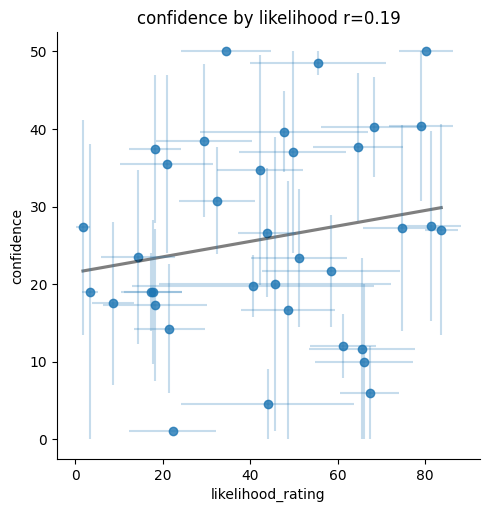

In [98]:
t1 = df.groupby(["consistent", "world", "worldtype", "probe_obj"]).agg(confidence=("confidence", "mean"), memory_sem=("confidence", "sem")).reset_index()
t2 = likelihood.groupby(["world", "worldtype", "probe_obj"]).agg(likelihood_rating=("response", "mean"), likelihood_sem=("response", "sem")).reset_index()
# t2
tmp = pd.merge(t1, t2, on=["world", "worldtype", "probe_obj"])
# tmp = tmp[~tmp.world.isin(["lh_ll_unlink_plinko_0048", "lh_ll_unlink_plinko_0061" ])]
p = sns.lmplot(tmp, x="likelihood_rating", y="confidence", ci=False, line_kws={"color": "black", "alpha": 0.5})
plt.errorbar(tmp.likelihood_rating, tmp.confidence, xerr=tmp.likelihood_sem, yerr=tmp.memory_sem, ls="none", alpha=0.25)
plt.title(f"confidence by likelihood r={tmp.confidence.corr(tmp.likelihood_rating):.2f}")


Text(0.5, 1.0, 'confidence by likelihood r=0.19')

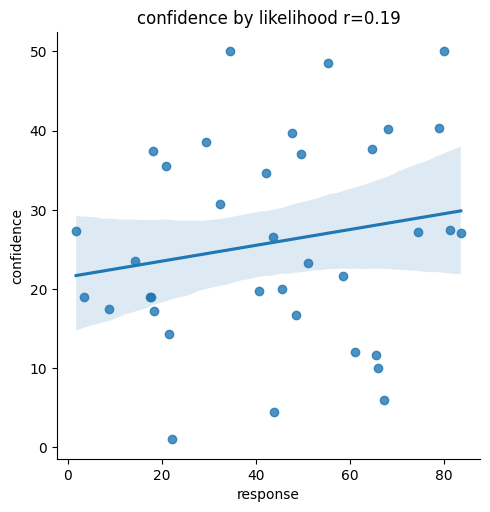

In [97]:
# df["response_1"] = np.abs(df.response - 50)
t1 = df.groupby(["world", "worldtype", "probe_obj"]).confidence.mean().reset_index()
tmp = pd.merge(# df.groupby(["world", "worldtype", "probe_obj"]).correct_conf.mean().reset_index(),
               t1,
               likelihood.groupby(["world", "worldtype", "probe_obj"]).response.mean().reset_index(),
               on=["world", "worldtype", "probe_obj"])
# tmp["consistent"] = tmp["probe_obj"] == tmp["worldtype"]
# tmp = tmp[~tmp.world.isin(["lh_ll_unlink_plinko_0048", "lh_ll_unlink_plinko_0061"])]

sns.lmplot(tmp, x="response", y="confidence")
plt.title(f"confidence by likelihood r={tmp.confidence.corr(tmp.response):.2f}")
# p = sns.lmplot(tmp, x="response", y="response_1", col="consistent")
# for consistent, ax in p.axes_dict.items():
#     subset = tmp[tmp.consistent == consistent]
#     ax.set_title(f"consistent={consistent}")
#     ax.set_xlabel("collision likelihood")
#     ax.set_ylabel("raw confidence")
# # plt.title(f"{tmp.correct_conf.corr(tmp.response):.2f}")

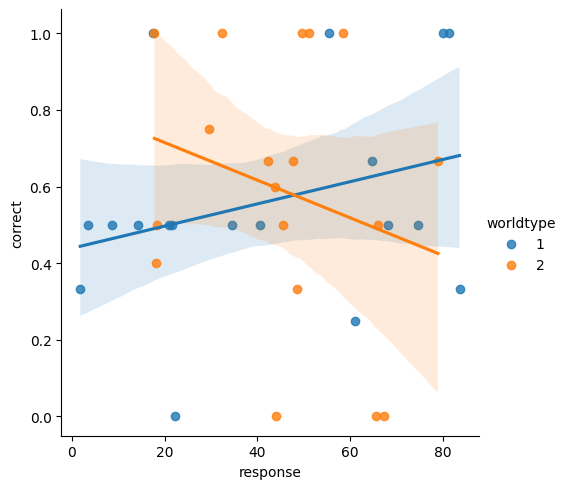

In [91]:
t1 = df.groupby(["world", "worldtype", "probe_obj"]).correct.mean().reset_index()
tmp = pd.merge(# df.groupby(["world", "worldtype", "probe_obj"]).correct_conf.mean().reset_index(),
               t1,
               likelihood.groupby(["world", "worldtype", "probe_obj"]).response.mean().reset_index(),
               on=["world", "worldtype", "probe_obj"])
tmp["consistent"] = tmp["probe_obj"] == tmp["worldtype"]

p = sns.lmplot(tmp, x="response", y="correct", hue="worldtype")
# for consistent, ax in p.axes_dict.items():
#     subset = tmp[tmp.consistent == consistent]
#     ax.set_title(f"consistent={consistent}")
#     ax.set_xlabel("collision likelihood")
#     ax.set_ylabel("accuracy")
# plt.title(f"{tmp.correct_conf.corr(tmp.response):.2f}")

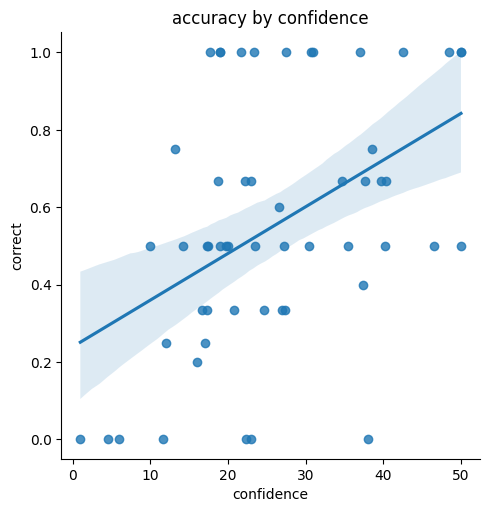

In [96]:
sns.lmplot(df.groupby(["world", "worldtype", "probe_obj"])[["correct", "confidence"]].mean().reset_index(), x="confidence", y="correct").set(title="accuracy by confidence")

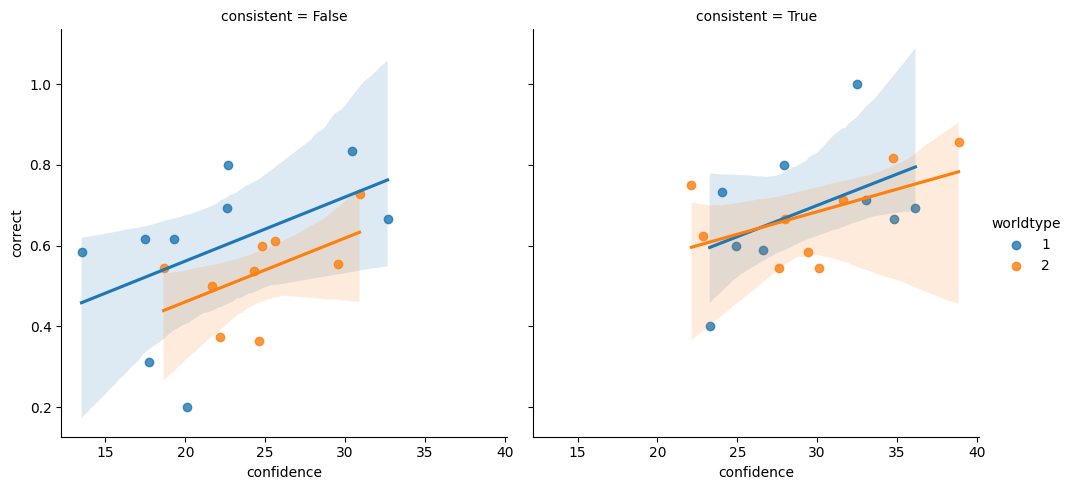

In [20]:
tmp1 = df.groupby(["world", "worldtype", "probe_obj", "consistent"])[["confidence", "correct"]].mean().reset_index()
p = sns.lmplot(tmp1, x="confidence", y="correct", col="consistent", hue="worldtype")
# for consistent, ax in p.axes_dict.items():
#     subset = df[df.consistent == consistent].groupby(["worldtype", "probe_obj"])[["correct_conf", "correct"]].mean().reset_index()
#     ax.set_title(f"consistent={consistent}")
#     ax.set_xlabel("collision likelihood")
#     ax.set_ylabel("memory accuracy")
# # plt.title(f"{tmp.correct_conf.corr(tmp.response):.2f}")


In [69]:
df.query("world == 'lh_ll_unlink_plinko_0048'").groupby(["worldtype", "probe_obj", "probe_shift_id"])[["response_1", "correct"]].count()
# df.query("consistent == False").groupby(["world", "worldtype", "probe_obj"])[["correct_conf"]].mean()

response_1  correct
worldtype probe_obj probe_shift_id                     
1         0         2                        1        1
          1         2                        2        2
          2         2                        4        4
2         0         1                        3        3
                    2                        3        3
          1         1                        1        1
                    2                        2        2
          2         1                        3        3

In [182]:
df.groupby(["world", "worldtype", "probe_obj"]).response.count()

world                     worldtype  probe_obj
lh_hl_unlink_plinko_0000  1          1            14
                                     2            14
                          2          1            11
                                     2             7
lh_ll_unlink_plinko_0001  1          1            16
                                     2            10
                          2          1             9
                                     2            11
lh_ll_unlink_plinko_0004  1          1            12
                                     2            12
                          2          1            11
                                     2            11
lh_ll_unlink_plinko_0007  1          1            15
                                     2            10
                          2          1            10
                                     2            11
lh_ll_unlink_plinko_0036  1          1            12
                                     2            12

In [ ]:
from ast import literal_eval
pred = pd.read_csv("predictions.csv")
pred["mae"] = 0

for idx, row in pred.iterrows():
    pred.loc[idx, "mae"] = sum(np.abs(row.true_x - np.array(literal_eval(row["clickPositions"])))) / 10

# normalize by maximum deviation for each world
pred["mae"] = pred.groupby("world")["mae"].transform(lambda x: x / x.max())
# look at people who were weird
weirdos = []

for idx, row in pred.query("world == 'catch'").iterrows():
    row_pred = literal_eval(row["clickPositions"])
    true_x = row.sim_x_result1 if row.worldtype == 1 else row.sim_x_result2
    if sum(abs(true_x - x) > 50 for x in row_pred) > 5:
        weirdos.append((row.pid, row.world, row.worldtype, max(abs(true_x - x) for x in row_pred)))
df_noweirdos = df[~df.pid.isin([w[0] for w in weirdos])]

(-4.100000000000001, 592.1, 0.0, 92.4)

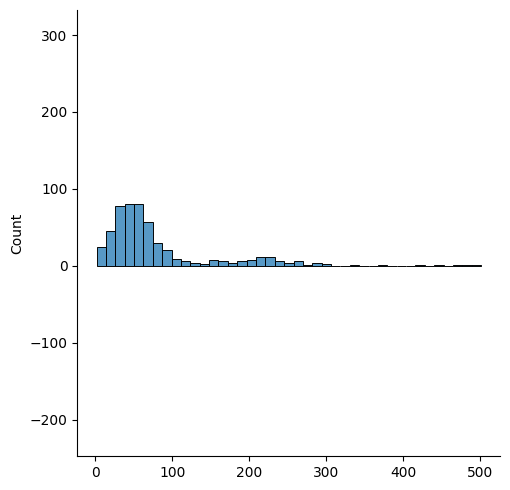

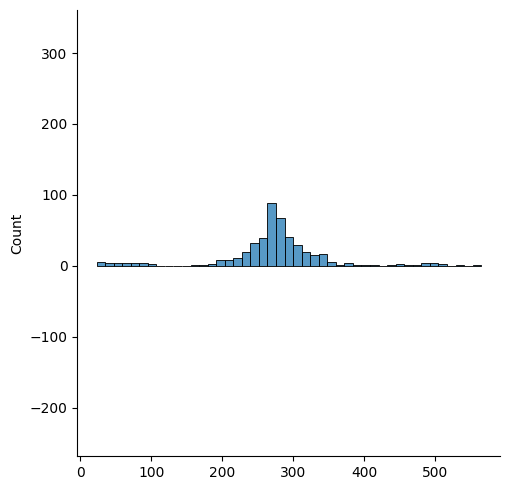

In [21]:
pred_catch1 = []
for idx, row in pred.query("(world == 'catch') & (worldtype == 1)").iterrows():
    pred_catch1.append(literal_eval(row["clickPositions"]))
pred_catch1 = np.array(pred_catch1).ravel()

pred_catch2 = []
for idx, row in pred.query("(world == 'catch') & (worldtype == 2)").iterrows():
    pred_catch2.append(literal_eval(row["clickPositions"]))
pred_catch2 = np.array(pred_catch2).ravel()

sns.displot(pred_catch1, kind="hist")
plt.axis("equal")
sns.displot(pred_catch2, kind="hist")
# plt.axis("off")
plt.axis("equal")

In [22]:
# look at people who were weird
weirdos = []

for idx, row in pred.query("world == 'catch'").iterrows():
    row_pred = literal_eval(row["clickPositions"])
    true_x = row.sim_x_result1 if row.worldtype == 1 else row.sim_x_result2
    if sum(abs(true_x - x) > 50 for x in row_pred) > 5:
        weirdos.append((row.pid, row.world, row.worldtype, max(abs(true_x - x) for x in row_pred)))

In [23]:
weirdos

[('6636396184346e2371d067ec', 'catch', 1, 449.33331298828125),
 ('6025504719183d063dd9239d', 'catch', 2, 250.0),
 ('63e8326b8d067b28655586fb', 'catch', 1, 173.0),
 ('6073765ad2cf968269c6775f', 'catch', 1, 322.515625),
 ('5d63179aa3b94d0001da4bb6', 'catch', 2, 238.38095092773438),
 ('66a9d46ff5d39bbede9f2e92', 'catch', 2, 253.0),
 ('572535bba34b2a001306827c', 'catch', 2, 257.6062469482422),
 ('66cd392e838ef435024cc78e', 'catch', 2, 247.484375),
 ('634868460f7419e22957fb59', 'catch', 2, 289.0),
 ('5ee6be54321536000905346a', 'catch', 1, 189.41250610351562),
 ('66b105e5472a7853291e7259', 'catch', 2, 133.41250610351562),
 ('5e121701dc79bd8a1a22ca99', 'catch', 2, 85.0),
 ('66b291dd6446b8f2ee477d8e', 'catch', 2, 226.515625),
 ('5fc7a6aaa7646c0009521161', 'catch', 1, 234.66665649414062)]

In [24]:
len(weirdos)

14

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_84680/3989966533.py:5: UserWarning: FixedFormatter should only be used together with FixedLocator
  p.set_xticklabels(["teleports", "doesn't teleport"])


Text(0, 0.5, 'confidence in correct answer')

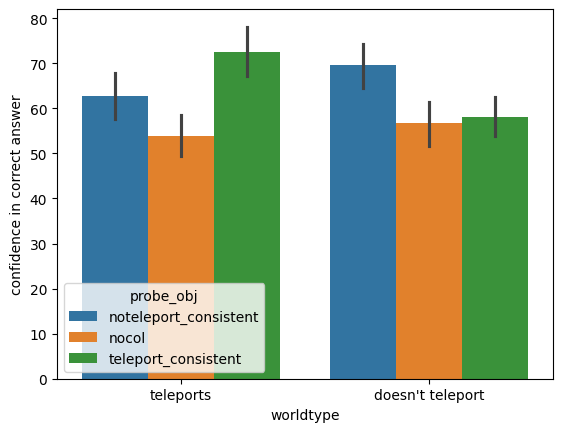

In [25]:
# df_weirdos = df[df.pid.isin([w[0] for w in weirdos])]
df_noweirdos = df[~df.pid.isin([w[0] for w in weirdos])]

p = sns.barplot(df_noweirdos, x="worldtype", y="correct_conf", hue="probe_obj", errorbar="ci", palette="tab10")
p.set_xticklabels(["teleports", "doesn't teleport"])
p.set_ylabel("confidence in correct answer")


In [26]:
from scipy.stats import ttest_ind

print(
    ttest_ind(
        df_noweirdos[df_noweirdos.consistent].correct_conf,
        df_noweirdos[~df_noweirdos.consistent].correct_conf,
    )
)
print(
    ttest_ind(
        df_noweirdos[
            (df_noweirdos.worldtype == 1) & (df_noweirdos.probe_obj == "teleport_consistent")
        ].correct_conf,
        df_noweirdos[
            (df_noweirdos.worldtype == 1) & (df_noweirdos.probe_obj == "noteleport_consistent")
        ].correct_conf,
    )
)
print(
    ttest_ind(
        df_noweirdos[
            (df_noweirdos.worldtype == 2) & (df_noweirdos.probe_obj == "teleport_consistent")
        ].correct_conf,
        df_noweirdos[
            (df_noweirdos.worldtype == 2) & (df_noweirdos.probe_obj == "noteleport_consistent")
        ].correct_conf,
    )
)
print(
    ttest_ind(
        df_noweirdos[
            (df_noweirdos.worldtype == 1) & (df_noweirdos.probe_obj == "teleport_consistent")
        ].correct_conf,
        df_noweirdos[
            (df_noweirdos.worldtype == 1) & (df_noweirdos.probe_obj != "teleport_consistent")
        ].correct_conf,
    )
)
print(
    ttest_ind(
        df_noweirdos[
            (df_noweirdos.worldtype == 2) & (df_noweirdos.probe_obj == "noteleport_consistent")
        ].correct_conf,
        df_noweirdos[
            (df_noweirdos.worldtype == 2) & (df_noweirdos.probe_obj != "noteleport_consistent")
        ].correct_conf,
    )
)


Ttest_indResult(statistic=6.086397033074622, pvalue=1.8275011160000918e-09)
Ttest_indResult(statistic=2.6154911148330875, pvalue=0.009467501785851958)
Ttest_indResult(statistic=-3.236274210660711, pvalue=0.0013662082395008756)
Ttest_indResult(statistic=4.571885928610222, pvalue=6.53814650849785e-06)
Ttest_indResult(statistic=4.094820674911992, pvalue=5.167412904711147e-05)


<Axes: xlabel='consistent', ylabel='correct_conf'>

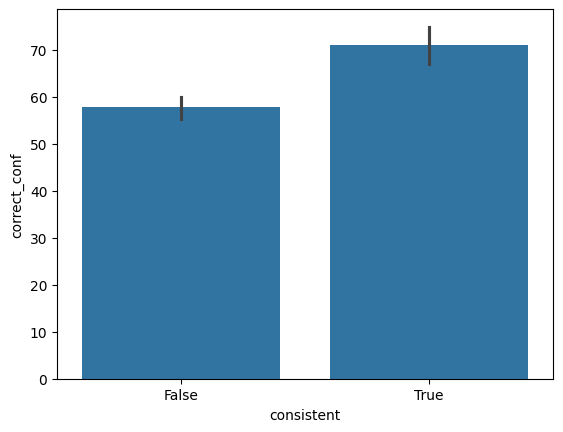

In [27]:
sns.barplot(df_noweirdos, x="consistent", y="correct_conf", errorbar="ci")

Text(0.5, 1.0, 'r=0.61')

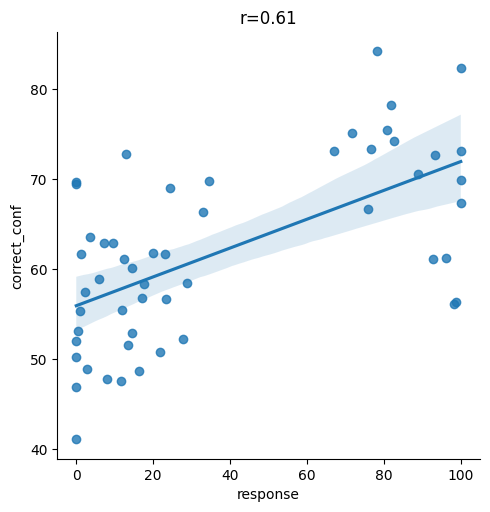

In [28]:
tmp_ = pd.merge(
    df_noweirdos.groupby(["world", "worldtype", "probe_obj"]).correct_conf.mean().reset_index(),
    likelihood.groupby(["world", "worldtype", "probe_obj"]).response.mean().reset_index(),
    on=["world", "worldtype", "probe_obj"],
)
tmp_["consistent"] = ((tmp_["worldtype"] == 1) & (tmp_["probe_obj"] == "teleport_consistent")) | (( tmp_["worldtype"] == 2) & (tmp_["probe_obj"] == "noteleport_consistent"))

sns.lmplot(tmp_, x="response", y="correct_conf")
plt.title(f"r={tmp_.correct_conf.corr(tmp_.response):.2f}")

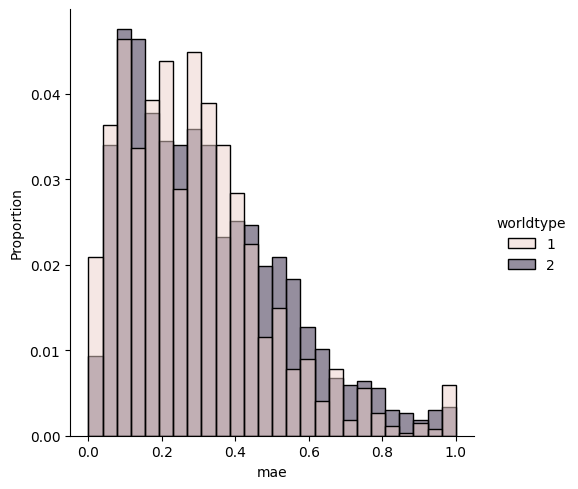

In [29]:
sns.displot(x="mae", stat="proportion", data=pred, hue="worldtype")

In [30]:
pred1 = pd.read_csv("../exp_bouncer_norm/predictions.csv")
pred1["mae"] = pred1.apply(mae, axis=1)

NameError: name 'mae' is not defined

In [31]:
pd.merge(
    pred.groupby(["world", "worldtype"]).mae.mean().reset_index(),
    pred1.groupby(["world", "worldType"]).mae.mean().reset_index().rename(columns={"worldType": "worldtype"}),
    # pred.groupby(["world"]).mae.mean().reset_index(),
    # pred1.groupby(["world"]).mae.mean().reset_index(),
    on=["world", "worldtype"],
).pipe(
    sns.lmplot, x="mae_x", y="mae_y", hue="worldtype"
).set(
    xlabel="mae (main exp)", ylabel="mae (norm exp)",
    title="mae for human predictions"
)

AttributeError: 'DataFrameGroupBy' object has no attribute 'mae'

In [40]:
# control - memory as function of number of objects
import json
no_cache = {}

def num_objects(x):
    if x.world in no_cache:
        return no_cache[x.world]
    with open(f"../../experiments/assets/exp_teleporter/targets/{x.world:04d}/{x.world:04d}_edited.json") as f:
        data = json.load(f)

    # don't count ball + walls
    no_cache[x.world] = len(data["world"]["objects"]) - 5
    return no_cache[x.world]

In [41]:
df["num_objects"] = df.apply(num_objects, axis=1)

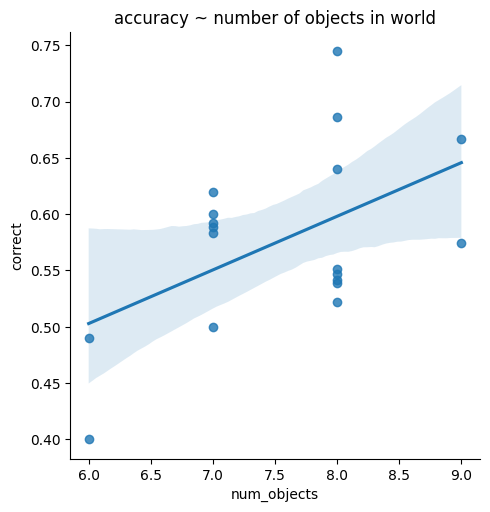

In [43]:
df.groupby(["world", "worldtype", "num_objects"]).correct.mean().reset_index().pipe(
    sns.lmplot, x="num_objects", y="correct"
).set(
    title="accuracy ~ number of objects in world"
)

In [45]:
df.probe_obj

0      noteleport_consistent
1                      nocol
2        teleport_consistent
3        teleport_consistent
4        teleport_consistent
               ...          
886    noteleport_consistent
887                    nocol
888    noteleport_consistent
889      teleport_consistent
890    noteleport_consistent
Name: probe_obj, Length: 891, dtype: object

In [47]:
# proximity to other objects

prox_cache = {}


def proximity(x):
    if x.world in prox_cache and x.probe_obj in prox_cache[x.world]:
        return prox_cache[x.world][x.probe_obj]
    with open(
        f"../../experiments/assets/exp_teleporter/targets/{x.world:04d}/{x.world:04d}_edited.json"
    ) as f:
        data = json.load(f)

    # obj_fname = x.probe_obj if x.probe_obj > 0 else "nocol"
    obj_fname = {"teleport_consistent": "1", "noteleport_consistent": "2", "nocol": "nocol"}[
        x.probe_obj
    ]
    transform_data = json.load(
        open(
            f"../../experiments/assets/exp_teleporter/targets/{x.world:04d}/base_{obj_fname}_red.json"
        )
    )

    probe_center = np.mean(
        np.array(data["world"]["objects"][transform_data["object"]]["vertices"]), axis=0
    )
    d = float("inf")
    for name, obj in data["world"]["objects"].items():
        if "Wall" in name or "FOCUS" in name or "goal" in name:
            continue

        if name == transform_data["object"]:
            continue

        obj_center = np.mean(np.array(obj["vertices"]), axis=0)
        if np.abs(obj_center - probe_center).sum() < d:
            d = np.abs(obj_center - probe_center).sum()
    prox_cache.setdefault(x.world, {})[x.probe_obj] = d
    return prox_cache[x.world][x.probe_obj]


df["proximity"] = df.apply(proximity, axis=1)

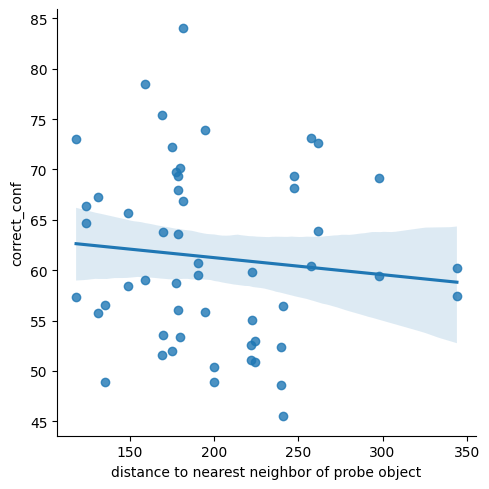

In [49]:
df.groupby(["world", "worldtype", "probe_obj"])[["proximity", "correct_conf"]].mean().reset_index().pipe(
    sns.lmplot, x="proximity", y="correct_conf"
).set(
    xlabel = "distance to nearest neighbor of probe object"
)

In [62]:
prox_ball_cache = {}


def proximity_ball(x):
    if x.world in prox_ball_cache and x.probe_obj in prox_ball_cache[x.world]:
        return prox_ball_cache[x.world][x.probe_obj]
    with open(
        f"../../experiments/assets/exp_teleporter/targets/{x.world:04d}/{x.world:04d}_edited.json"
    ) as f:
        data = json.load(f)

    # obj_fname = x.probe_obj if x.probe_obj > 0 else "nocol"
    obj_fname = {"teleport_consistent": "1", "noteleport_consistent": "2", "nocol": "nocol"}[
        x.probe_obj
    ]
    transform_data = json.load(
        open(
            f"../../experiments/assets/exp_teleporter/targets/{x.world:04d}/base_{obj_fname}_red.json"
        )
    )

    probe_center = np.mean(
        np.array(data["world"]["objects"][transform_data["object"]]["vertices"]), axis=0
    )
    d = float("inf")
    for pos in data["displayPath"]["FOCUS"]:
        # print(x)
        if np.abs(np.array(pos[:2]) - probe_center).sum() < d:
            d = np.abs(np.array(pos[:2]) - probe_center).sum()
    for pos in data["displayPath1"]["FOCUS"]:
        # print(x)
        if np.abs(np.array(pos[:2]) - probe_center).sum() < d:
            d = np.abs(np.array(pos[:2]) - probe_center).sum()
    # for name, obj in data["world"]["objects"].items():
    #     if "Wall" in name or "FOCUS" in name or "goal" in name:
    #         continue

    #     if name == transform_data["object"]:
    #         continue

    #     obj_center = np.mean(np.array(obj["vertices"]), axis=0)
    #     if np.abs(obj_center - probe_center).sum() < d:
    #         d = np.abs(obj_center - probe_center).sum()
    prox_ball_cache.setdefault(x.world, {})[x.probe_obj] = d
    return prox_ball_cache[x.world][x.probe_obj]


df["ball_proximity"] = df.apply(proximity_ball, axis=1)


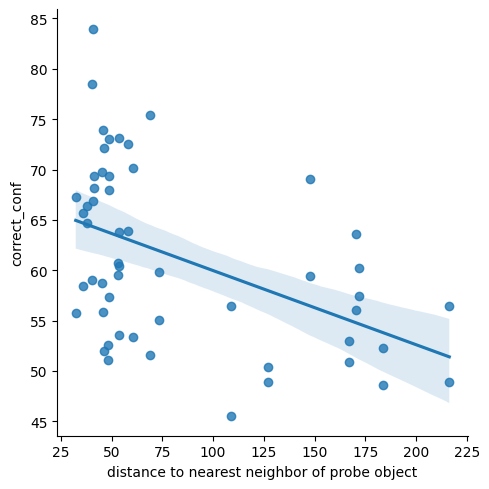

In [64]:
df.groupby(["world", "worldtype", "probe_obj"])[["ball_proximity", "correct_conf"]].mean().reset_index().pipe(
    sns.lmplot, x="ball_proximity", y="correct_conf"
).set(
    xlabel = "distance to nearest neighbor of probe object"
)
